In [34]:
%pip install pandas pyarrow ydata-profiling catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.8/102.4 MB 3.5 MB/s eta 0:00:30
   - -------------------------------------- 4.2/102.4 MB 11.1 MB/s eta 0:00:09
   -- ------------------------------------- 6.3/102.4 MB 10.5 MB/s eta 0:00:10
   --- ------------------------------------ 8.1/102.4 MB 10.3 MB/s eta 0:00:10
   --- ------------------------------------ 10.2/102.4 MB 9.9 MB/s eta 0:00:10
   ---- ----------------------------------- 11.5/102.4 MB 9.9 MB/s eta 0:00:10
   ----- ---------------------------------- 13.9/102.4 MB 9.6 MB/s eta 0:00:10
   ------ --------------------------------- 15.7/102.4 MB 9.8 MB/s eta 0:00:09
   ------ --------------------------------- 17.8/102.4 MB 9.6 MB/s eta 0:00:09
   ------- -------------------------------- 19.7/102.4 MB 9.4 MB/s eta 0:00:09
   -------- ------------------------------- 21.5/102.4 MB 9.3 MB/s et


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
%matplotlib inline

### Файлы train.parquet и test.parquet содержат:
+ `nm_id` - анонимный идентификатор товара.
+ `dt` - дата.
+ `price` - цена товара в этот день.
+ `is_promo` - флаг участия товара в промо-акции.
+ `prev_leftovers` - остаток товара на складе на начало дня.
+ `qty` - количество проданных единиц, присутствует только в train. Это ваш таргет.

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
from catboost import CatBoostClassifier, CatBoostRegressor
from ydata_profiling import ProfileReport

In [36]:
train_df = pd.read_parquet("train.parquet", engine="pyarrow")
test_df = pd.read_parquet("test.parquet", engine="pyarrow")
train_df["__is_train"] = 1
test_df["__is_train"] = 0
full_df = pd.concat([train_df, test_df], ignore_index=True)
display(full_df.head(5))

,nm_id,dt,qty,price,is_promo,prev_leftovers,__is_train
0,015ecac1-0d4d-4272-9f9c-7c62a742a679,2024-07-04,0.0,2940,0,54,1
1,02790618-93a6-4a2e-92e2-72cbb0bf24cf,2024-07-04,3.0,6543,0,75,1
2,03cf7d0c-4709-409d-a964-44558ada7e3d,2024-07-04,3.0,4983,0,66,1
3,0407f293-33e5-4c34-8236-9ddef5a166f0,2024-07-04,3.0,1971,1,132,1
4,046336e9-58cd-4d0f-b521-c70607fd9ec4,2024-07-04,0.0,2133,1,87,1


In [37]:
def add_russian_calendar_features(
    df: pd.DataFrame, dt_column: str = "dt"
) -> pd.DataFrame:
    df = df.copy()
    df[dt_column] = pd.to_datetime(df[dt_column]).dt.normalize()

    holidays = set()
    preholidays = set()

    for year in (2024, 2025):
        url = (
            "https://raw.githubusercontent.com/d10xa/holidays-calendar/"
            f"master/json/consultant{year}.json"
        )
        calendar = requests.get(url, timeout=10).json()

        holidays.update(pd.to_datetime(calendar["holidays"]))
        preholidays.update(pd.to_datetime(calendar["preholidays"]))

    df["is_preholiday"] = df[dt_column].isin(preholidays)

    df["is_non_working_day_rus"] = (
        df[dt_column].isin(holidays)
        | (df[dt_column].dt.weekday >= 5)
    )

    return df

In [38]:
full_df = add_russian_calendar_features(full_df)

In [39]:
full_df["day_of_week"] = full_df["dt"].dt.day_of_week
full_df["day"] = full_df["dt"].dt.day
full_df["month"] = full_df["dt"].dt.month
full_df["week_of_year"] = full_df["dt"].dt.isocalendar().week
full_df["is_weeked"] = full_df["day_of_week"].isin([5, 6])
full_df = full_df.sort_values(by="dt")
full_df.head(3)

,nm_id,dt,qty,price,is_promo,prev_leftovers,__is_train,is_preholiday,is_non_working_day_rus,day_of_week,day,month,week_of_year,is_weeked
0,015ecac1-0d4d-4272-9f9c-7c62a742a679,2024-07-04,0.0,2940,0,54,1,False,False,3,4,7,27,False
129,992511ca-b659-4617-b62f-b44716689d06,2024-07-04,0.0,18261,0,33,1,False,False,3,4,7,27,False
130,99e6d1ca-04c0-4c4a-9f0b-1d65c5988efd,2024-07-04,0.0,3810,1,51,1,False,False,3,4,7,27,False


In [40]:
train_df = full_df[full_df["__is_train"] == 1].copy()
test_df = full_df[full_df["__is_train"] == 0].copy()
train_df["sale"] = (train_df["qty"] > 0).astype(int)

In [41]:
FEATURES = [
    "price",
    "is_promo",
    "prev_leftovers",
    "is_preholiday",
    "is_non_working_day_rus",
    "day_of_week",
    "day",
    "month",
    "week_of_year",
    "is_weeked",
]

In [42]:
clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
)

clf.fit(
    train_df[FEATURES],
    train_df["sale"]
)

In [43]:
train_sales = train_df[train_df["sale"] == 1]

In [46]:
reg = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="MAE",
    verbose=False,
)

reg.fit(
    train_sales[FEATURES],
    train_sales["qty"]
)

In [47]:
test_df["sale_pred"] = clf.predict(test_df[FEATURES])
test_df["qty_pred"] = reg.predict(test_df[FEATURES])

test_df["qty_final"] = test_df["sale_pred"] * test_df["qty_pred"]
test_df["qty_final"] = test_df["qty_final"].clip(lower=0)

submission = test_df[["nm_id", "dt", "qty_final"]].rename(
    columns={"qty_final": "qty"}
)

submission.to_csv("submission.csv", index=False)

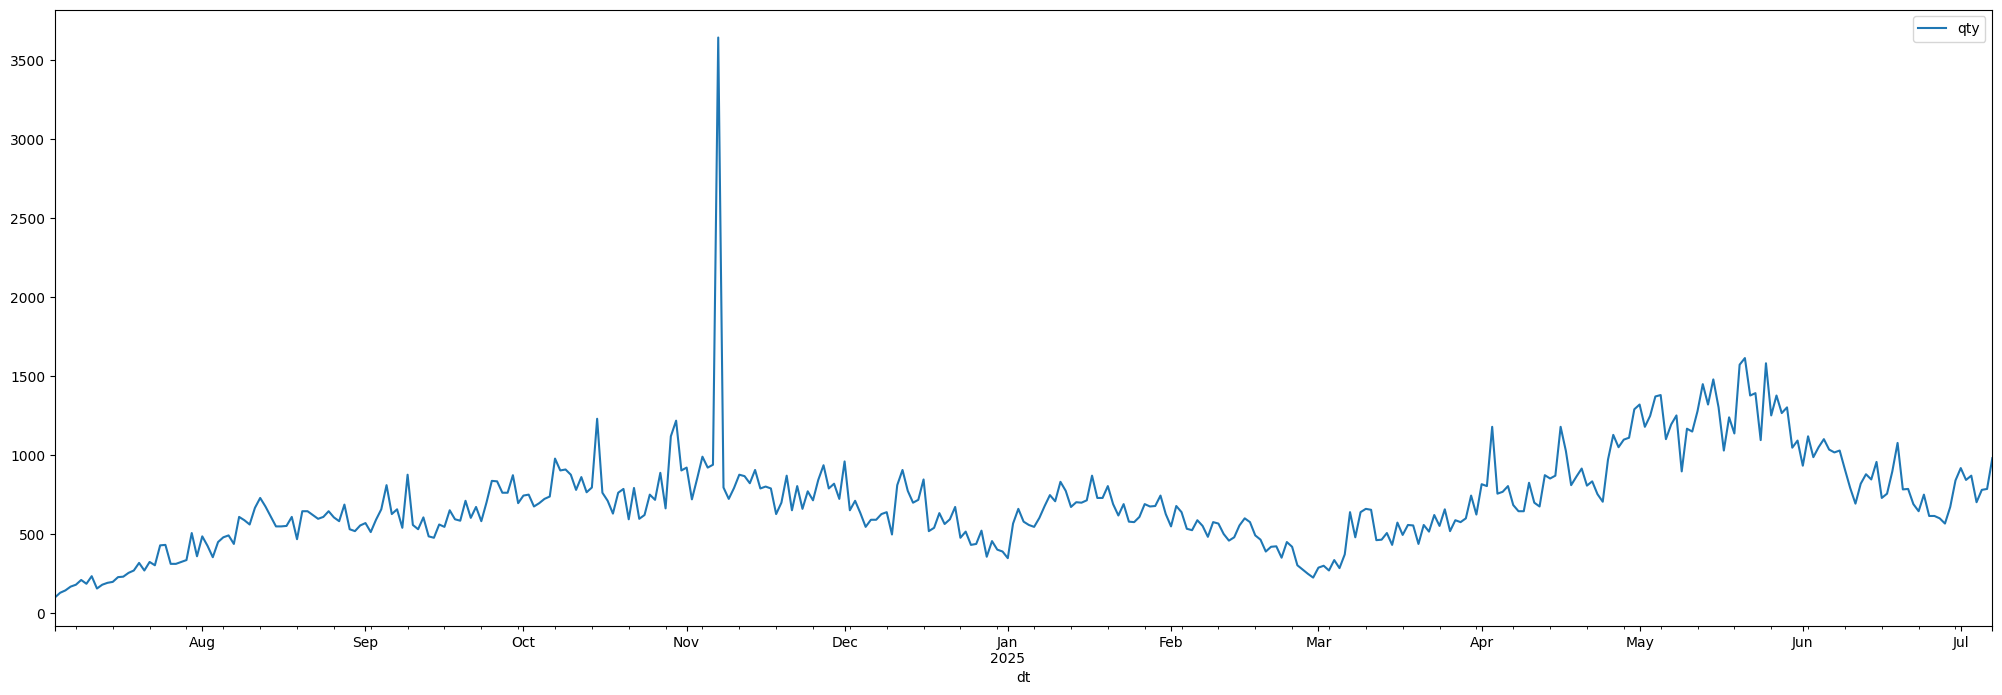

In [54]:
sum_qty_df = pd.DataFrame(train_df.groupby(by=["dt"])["qty"].sum())
sum_qty_df.plot()
plt.show()

In [ ]:
sum_qty_df[sum_qty_df["qty"] > 3000]
anomal_day = pd.to_datetime("2024-11-07")

,qty
dt,
2024-11-07,3642


In [56]:
sum_qty_df.describe()

,qty
count,369.000000
mean,709.845528
std,314.034520
min,99.000000
25%,549.000000
50%,672.000000
75%,837.000000
max,3642.000000


In [ ]:
anomal_day_series = (
    train_df[train_df["dt"] == anomal_day]
    .groupby(by=["nm_id"])["qty"]
    .sum()
)
anomal_day_series[anomal_day_series > 0].sort_values(ascending=False)

nm_id
9e929d98-a3d1-41d1-b78e-234f85580c06    213
e9d72ebc-9d36-472f-bc8c-e5ed57b085ae    162
7ad1b5f1-d0a5-4910-ad8b-05055fcce9d0    120
9eda9cbb-af4d-4156-85df-11ff1efc9e2d    120
855398bb-f279-49f7-8ce7-f5c067adaec7    117
                                       ... 
e1616ce8-fbc1-4490-b353-633011e06b83      3
f5436cdd-8af7-4043-b334-2e51393bcc79      3
f9cf8eab-ad38-41e5-9d6b-970c182fa1a0      3
fab25ff0-ba23-47a7-8b8b-aae3145738b9      3
ff764c76-a612-47aa-bdfd-a094eee08266      3
Name: qty, Length: 230, dtype: int64

In [ ]:
full_df["is_anomaly_day"] = full_df["dt"] == anomal_day

,nm_id,dt,qty,price,is_promo,prev_leftovers,is_anomaly_day
0,015ecac1-0d4d-4272-9f9c-7c62a742a679,2024-07-04,0,2940,0,54,False
1,02790618-93a6-4a2e-92e2-72cbb0bf24cf,2024-07-04,3,6543,0,75,False
2,03cf7d0c-4709-409d-a964-44558ada7e3d,2024-07-04,3,4983,0,66,False
3,0407f293-33e5-4c34-8236-9ddef5a166f0,2024-07-04,3,1971,1,132,False
4,046336e9-58cd-4d0f-b521-c70607fd9ec4,2024-07-04,0,2133,1,87,False
...,...,...,...,...,...,...,...
309643,fe889206-2bfe-4c6e-98c5-88ebfae5295f,2025-07-07,0,3747,1,12,False
309644,fef549dd-9fe5-4cf2-b9f0-2539c103a4f2,2025-07-07,0,10647,1,36,False
309645,ff0d747b-bdc1-4628-8163-8fcc27eed4bc,2025-07-07,0,10248,0,78,False
309646,ff518e5b-e28f-41f9-9610-bf9f6bdbe334,2025-07-07,0,39762,1,105,False


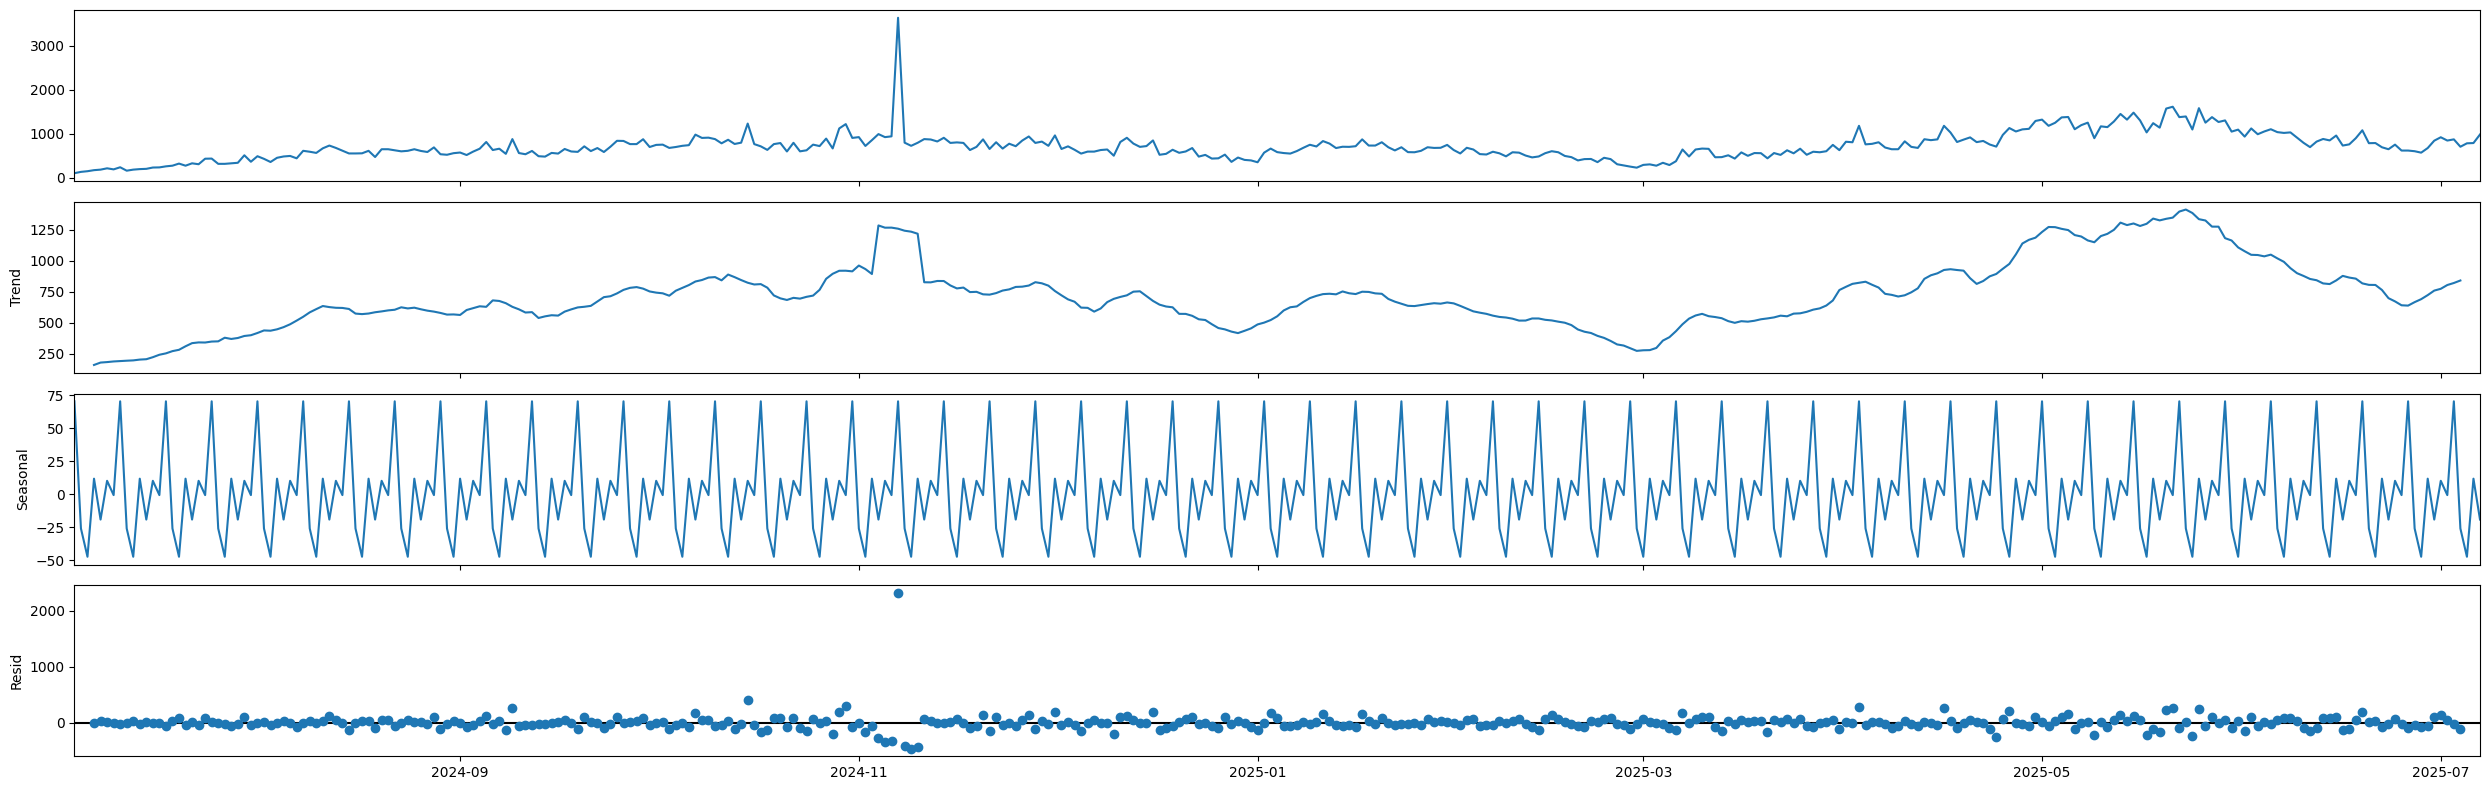

In [ ]:
res = sm.tsa.seasonal_decompose(sum_qty_df)
plt.rc("figure", figsize=(25, 8))
resplot = res.plot()

<Axes: >

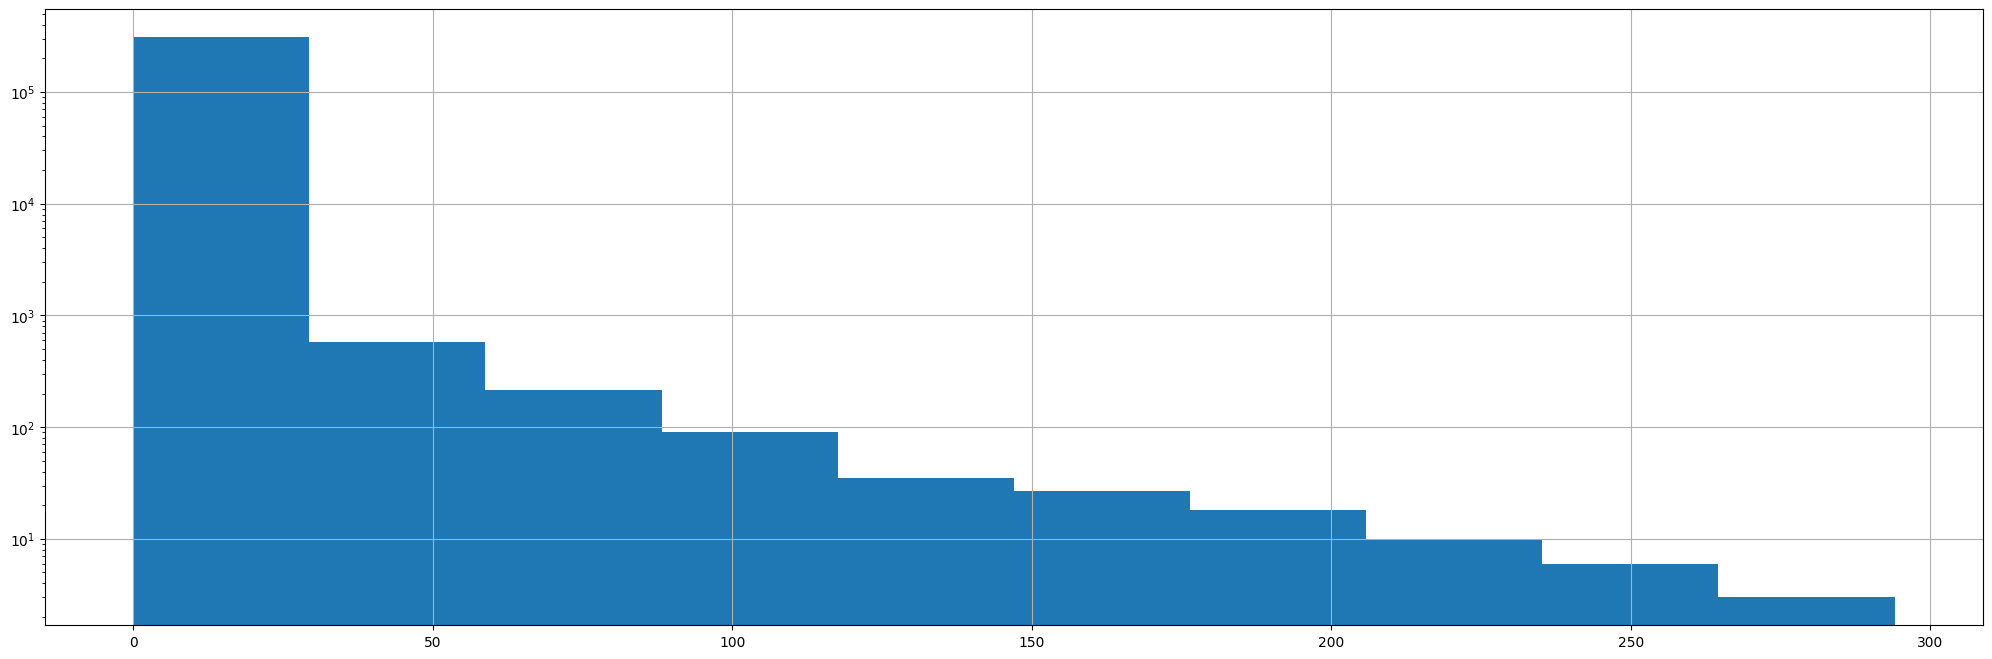

In [ ]:
train_df["qty"].hist(log=True)

In [52]:
profile = ProfileReport(
    train_df, title="Train Data Profile Report", explorative=True
)
profile.to_file("train_data_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 210.68it/s]
